# Exploratory Data Analysis — FDA Adverse Event Signal Detector

This notebook explores the cleaned, feature-engineered FDA adverse event dataset (FAERS, accessed via the openFDA API [1,2]) ahead of model training. The data covers 23,173 unique reports across 15 target drugs spanning several therapeutic categories (pain/NSAID, diabetes, cardiovascular, mental health, opioid, antibiotic, thyroid).

FAERS is a spontaneous, voluntary reporting system. FDA states directly that the presence of a report does not mean the reported product caused the event [6], and the database lacks a defined denominator, meaning true incidence rates cannot be calculated from it [8]. The data is also subject to known limitations including duplicate and incomplete reports [6,7], reporting bias toward serious events [9], the "Weber effect" (reporting historically peaks around two years after a drug's approval) [3], and "stimulated reporting" (reporting spikes following FDA safety alerts or label changes) [4].

Data was fetched, deduplicated, and structured into a three-table relational schema (`reports`, `drugs`, `reactions`) in `src/build_database.py`, with two additional engineered features (`reaction_count`, `drug_count`) added via SQL in `src/feature_engineering.py`. This notebook picks up from that database.

In [47]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Data

Connecting to the database and pulling the `reports` table into a dataframe for exploration.

In [29]:
conn = sqlite3.connect("../data/fda_adverse_events.db")
df = pd.read_sql_query("SELECT * FROM reports", conn)

In [30]:
df.head()

,safetyreportid,serious,seriousnessdeath,seriousnesshospitalization,seriousnessdisabling,seriousnesslifethreatening,patientonsetage,patientonsetageunit,patientsex,receivedate,reaction_count,drug_count,patientonsetage_years
0,10003301,1,NaN,NaN,NaN,NaN,NaN,NaN,2,20140228,2,1,NaN
1,10003319,1,NaN,1,NaN,NaN,46.0,801,2,20140312,4,10,46.0
2,10003865,1,NaN,1,NaN,NaN,18.0,801,2,20140312,2,10,18.0
3,10004019,1,NaN,1,NaN,NaN,33.0,801,2,20140312,2,3,33.0
4,10004183,2,NaN,NaN,NaN,NaN,54.0,801,1,20140312,1,4,54.0


In [31]:
df.shape

(23173, 13)

## Age Check

Before exploring age's relationship with seriousness, checking the raw `patientonsetage` column for any implausible values.

In [18]:
df.describe()

,patientonsetage,reaction_count,drug_count
count,19084.000000,23173.000000,23173.000000
mean,110.226210,4.031114,8.174859
std,1104.830623,5.462774,8.029334
min,0.000000,1.000000,1.000000
25%,49.000000,1.000000,3.000000
50%,62.000000,3.000000,6.000000
75%,73.000000,5.000000,11.000000
max,33071.000000,200.000000,304.000000


In [19]:
df["patientonsetageunit"].value_counts()

patientonsetageunit
801    18827
804      104
802       81
800       61
803        9
805        2
Name: count, dtype: int64

In [22]:
df["patientonsetage_years"].describe()

count    19084.000000
mean        59.182417
std         18.799902
min          0.000000
25%         49.000000
50%         62.000000
75%         73.000000
max        102.000000
Name: patientonsetage_years, dtype: float64

## Class Balance: Serious Outcomes

Before looking at individual features, checking how reports are distributed between serious and non-serious outcomes.

In [32]:
df["serious"].dtype

<StringDtype(na_value=nan)>

In [33]:
serious_map = {"1": "Serious", "2": "Not Serious"}
df["serious_label"] = df["serious"].map(serious_map)

In [34]:
df["serious_label"].value_counts()

serious_label
Serious        18322
Not Serious     4851
Name: count, dtype: int64

<Axes: xlabel='serious_label', ylabel='count'>

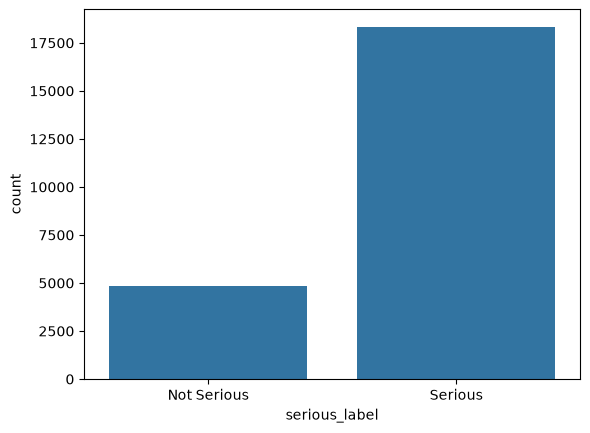

In [35]:
sns.countplot(data=df, x="serious_label", order=["Not Serious", "Serious"])

The dataset is imbalanced towards serious outcomes as 18,322 reports (79%) are marked serious, compared to 4,851 (21%) not serious. This is different balance than a typical clinical dataset, possibly reflecting FAERS's voluntary reporting, which is influenced by a documented tendency to report serious events more than non-serious ones [9].

This imbalance will need to be accounted for during modeling. A model could achieve high accuracy simply by always predicting "Serious," without actually learning anything useful. Precision, recall, and class-specific metrics will matter more than overall accuracy.

## Reaction Count and Drug Count Distributions

Looking at the two engineered features before checking their relationship to seriousness.

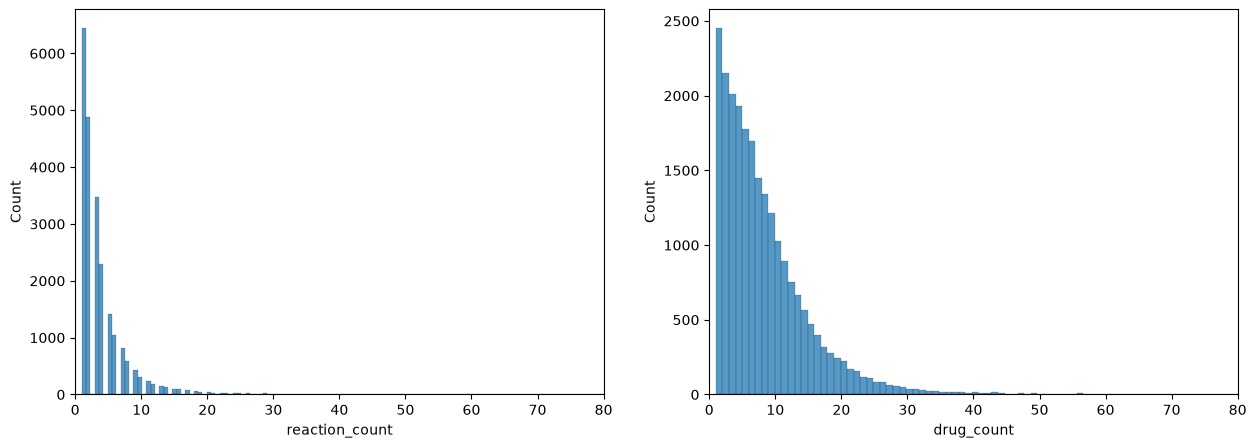

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=df, x="reaction_count", ax=axes[0])
axes[0].set_xlim(0, 80)
sns.histplot(data=df, x="drug_count", ax=axes[1])
axes[1].set_xlim(0, 80)
plt.show()

Both reaction_count and drug_count are strongly right-skewed. Zooming into 0-80 shows the shape clearly: reaction_count drops off sharply, with the large majority of reports listing fewer than 10 reactions. drug_count has a noticeably wider spread, declining more gradually out toward 30-40 before thinning out. A small number of reports fall well outside this range entirely (up to 200 reactions in one case, up to 304 drugs in another (confirmed via `df.describe()`)) not visible in this zoomed-in view.

This kind of long tail is worth keeping in mind for modeling: a few extreme reports could disproportionately influence a model.

Reports with unusually high drug_count may reflect polypharmacy (patients on multiple concurrent medications), a recognized and frequently-studied pattern in FAERS case series [5], though this hasn't been directly verified against the specific high-drug_count reports in this dataset, and remains a hypothesis worth investigating further rather than a confirmed explanation.

## Age vs. Seriousness

Checking whether patient age relates to report seriousness, using the corrected patientonsetage_years column.

<Axes: xlabel='serious_label', ylabel='patientonsetage_years'>

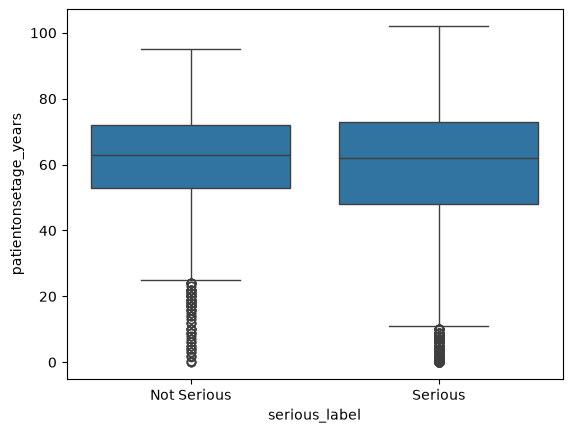

In [37]:
sns.boxplot(data=df, x="serious_label", y="patientonsetage_years", order=["Not Serious", "Serious"])

Patient age shows a weak or unclear relationship with report seriousness. The median age is nearly identical between Not Serious (~63) and Serious (~62) reports, and the two boxes overlap substantially (roughly 53-72 vs. 48-73). Both groups show a cluster of low-age outliers near the bottom, likely reflecting paediatric adverse event cases in both categories.

This is an important negative finding as it suggests that age alone is unlikely to be a strong predictor of seriousness in this dataset, meaning the model will likely need to rely more heavily on other features such as reaction_count, drug_count, or drug category, rather than patient age.

## Correlation Between Numeric Features

Checking how the numeric features relate to each other, to spot any redundancy and get one consolidated view before moving to drug-level comparisons.

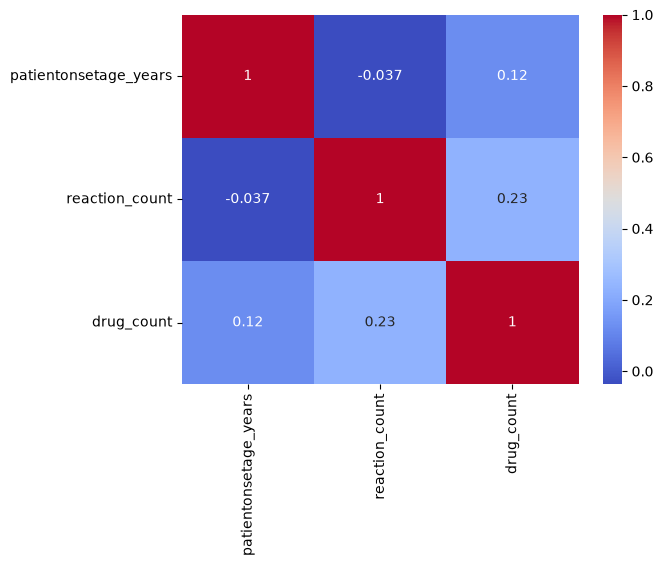

In [38]:
correlation_matrix = df[["patientonsetage_years", "reaction_count", "drug_count"]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.show()

None of the three numeric features show a strong correlation with each other. patientonsetage_years is essentially uncorrelated with reaction_count (-0.037) and only weakly correlated with drg_count (0.12), reinforcing the earlier finding that age carries little signal in this dataset. reaction_count and drug_count show a mild positive correlation (0.23), reports listing more drugs tend to also list somewhat more reactions, though the relationship is far from strong, suggesting the two features capture meaningfully different information rather than duplicating each other.

Overall, this small set of numeric features shows limited redundancy, meaning each is likely to contribute at least some independent signal to a model rather than one making the others unnecessary.

## Joining Reports and Drugs

So far, this notebook has only queried the `reports` table on its own. To compare seriousness across drugs, drug names (stored in `drugs`) need to be combined with each report's seriousness flag (stored in `reports`), matching rows on the shared `safetyreportid` column.

In [42]:
drug_serious_df = pd.read_sql_query("SELECT drugs.medicinalproduct," \
"reports.serious " \
"FROM drugs JOIN reports " \
"ON drugs.safetyreportid = reports.safetyreportid", conn)

In [44]:
drug_serious_df.head()

,medicinalproduct,serious
0,IBUPROFEN,1
1,BENLYSTA,1
2,PLAQUENIL,1
3,FOLTX,1
4,CYMBALTA,1


In [45]:
drug_serious_df.shape

(189436, 2)

In [48]:
TARGET_DRUGS = [
    "Ibuprofen",
    "Aspirin",
    "Acetaminophen",
    "Metformin",
    "Insulin glargine",
    "Atorvastatin",
    "Lisinopril",
    "Warfarin",
    "Apixaban",
    "Sertraline",
    "Alprazolam",
    "Oxycodone",
    "Amoxicillin",
    "Gabapentin",
    "Levothyroxine",
]

drug_serious_df["drug_upper"] = drug_serious_df["medicinalproduct"].str.upper()
target_upper = [d.upper() for d in TARGET_DRUGS]

filtered_df = drug_serious_df[drug_serious_df["drug_upper"].isin(target_upper)]

In [49]:
filtered_df.shape
filtered_df["drug_upper"].value_counts()

drug_upper
APIXABAN            2223
METFORMIN           2035
ASPIRIN             1912
WARFARIN            1715
GABAPENTIN          1687
ATORVASTATIN        1667
LISINOPRIL          1622
SERTRALINE          1502
LEVOTHYROXINE       1491
IBUPROFEN           1330
OXYCODONE           1199
ALPRAZOLAM           847
ACETAMINOPHEN        602
AMOXICILLIN          592
INSULIN GLARGINE     440
Name: count, dtype: int64

In [54]:
filtered_df["is_serious"] = (filtered_df["serious"] == "1").astype(int)

In [56]:
filtered_df.groupby("drug_upper")["is_serious"].mean().sort_values(ascending=False)

drug_upper
APIXABAN            0.922627
INSULIN GLARGINE    0.918182
ACETAMINOPHEN       0.901993
SERTRALINE          0.892810
ATORVASTATIN        0.846431
AMOXICILLIN         0.832770
WARFARIN            0.822741
METFORMIN           0.790663
OXYCODONE           0.771476
ALPRAZOLAM          0.731995
IBUPROFEN           0.721053
ASPIRIN             0.718619
LEVOTHYROXINE       0.691482
LISINOPRIL          0.678792
GABAPENTIN          0.579135
Name: is_serious, dtype: float64

Percentage of reports marked serious varies meaningfully across the 15 drugs, from 57.9% (Gabapentin) to 92.3% (Apixaban).

A few results are worth noting:

- Apixaban and Warfarin, which are both anticoagulants, sit at different ends of the range (92.3% and 82.3% respectively) rather than clustering closely together.
- Oxycodone (77.1%) and Gabapentin (57.9%) do not rank among the highest, despite both carrying well-documented safety concerns in the wider literature. Oxycodone for its addictive potential and association with opioid-related mortality [12], and gabapentin for its recognized misuse and abuse potential [10,11]. Gabapentin is in fact the lowest of all 15 drugs in this dataset. This counters initial expectation that these drugs would show the highest proportion of serious reports in FAERS.

**Important note:** this percentage does not represent the real-world risk of taking a given drug. Every row in this dataset is already an adverse event report as there is no comparison group of unaffected patients, and FAERS lacks a defined denominator, meaning incidence rates cannot be calculated from it [8]. 

## Summary of Findings

- The dataset is imbalanced toward serious outcomes overall. 79% of reports are marked serious, 21% not. This imbalance needs to be accounted for during modeling (precision/recall over raw accuracy).
- reaction_count and drug_count are both strongly right-skewed, with a long tail of extreme multi-drug/multi-reaction reports. A mild positive correlation (0.23) suggests they capture partially distinct information.
- A real data quality issue was found and corrected. Raw patientonsetage mixed multiple units (years, decades, months, weeks, days, hours) without conversion, producing implausible values up to 33,071. Corrected via a new engineered feature, patientonsetage_years.
- Patient age shows a weak relationship with report seriousness. It is unlikely to be a strong standalone predictor.
- The proportion of reports marked serious varies substantially by drug (58%-92%), with results that partly contradict an assumption that opioids/controlled substances would rank highest. This should be read as a reporting pattern, not a direct measure of clinical risk, given FAERS's lack of a defined denominator.

**Implication for modeling:** reaction_count, drug_count, and drug identity itself appear likely to carry more predictive signal than patient age. The class imbalance in the target (serious vs. not serious) will need to be explicity handled during model training and evaluation.

## References

1. U.S. Food and Drug Administration. FDA Adverse Event Reporting System (FAERS). https://www.fda.gov/drugs/surveillance/fdas-adverse-event-reporting-system-faers

2. openFDA. FDA Adverse Event Reporting System dataset documentation. https://open.fda.gov/data/faers

3. Sakaeda T, Tamon A, Kadoyama K, Okuno Y. Data mining of the public version of the FDA Adverse Event Reporting System. *International Journal of Medical Sciences*. https://link.springer.com/doi/10.1007/s40264-014-0150-2

4. Hoffman KB, et al. Stimulated reporting: the impact of FDA-issued alerts on the adverse event reporting system (FAERS). *Drug Safety*. https://link.springer.com/article/10.1007/s40264-014-0225-0

5. BRASH syndrome as a clinical syndrome driven by polypharmacy: a pharmacovigilance study of 1,081 cases from FAERS. *medRxiv*. https://www.medrxiv.org/content/10.64898/2026.01.15.26344203v1.full

6. U.S. Food and Drug Administration. FDA Adverse Event Monitoring System (AEMS) Public Dashboard. https://www.fda.gov/drugs/fda-adverse-event-monitoring-system-aems/fda-adverse-event-monitoring-system-aems-public-dashboard

7. Evaluation of Duplicate Adverse Event Reports Characteristics in the Food and Drug Administration Adverse Event Reporting System. *Drug Safety*. https://link.springer.com/article/10.1007/s40264-025-01560-7

8. Letter re: Xing et al. FAERS/lecanemab pharmacovigilance study. *Alzheimer's Research & Therapy*. https://alzres.biomedcentral.com/articles/10.1186/s13195-025-01735-5

9. Utility and limitations of the FDA adverse events reporting system public dashboard for safety analyses: a case study with VMAT2 inhibitors. https://www.tandfonline.com/doi/full/10.1080/14740338.2025.2588634

10. Smith RV, Havens JR, Walsh SL. Gabapentin misuse, abuse and diversion: a systematic review. *Addiction*. https://onlinelibrary.wiley.com/doi/abs/10.1111/add.13324

11. Peckham AM, Ananickal MJ, Sclar DA. Gabapentin use, abuse, and the US opioid epidemic: the case for reclassification as a controlled substance and the need for pharmacovigilance. *Risk Management and Healthcare Policy*. https://www.dovepress.com/gabapentin-use-abuse-and-the-us-opioid-epidemic-the-case-for-reclassif-peer-reviewed-fulltext-article-RMHP

12. Oxycodone-related deaths in Sweden 2006-2018. https://www.sciencedirect.com/science/article/pii/S0376871622001399